# Binary Fit to Experimental Data

## Goal
In this tutorial, you will learn how to fit the soft interaction parameters ($\varepsilon$ and $\varepsilon_{TS}$) to experimental protein stability data using the binary crowding model.

We will use experimental data for the AQ16 peptide in the presence of Trehalose.

## Setup
First, we import the package, as well as `pandas` for data handling and `matplotlib` for plotting.

In [1]:
import fh_crowding
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print(f"Module imported successfully: {fh_crowding.__name__}")

Module imported successfully: fh_crowding


## Load Experimental Data
The package includes sample datasets in `app/sample_data/`. Let's load the binary Trehalose dataset. 

This dataset has the following columns:
- `concentration`: The concentration of Trehalose in **Molal** ($m$).
- `dG`: $\Delta\Delta G$ in **kJ/mol**.
- `dH`: $\Delta\Delta H$ in **kJ/mol**.
- `TdS`: $T\Delta\Delta S$ in **kJ/mol**.

*Note that missing values are represented as empty cells (which Pandas parses as `NaN`).*

In [2]:
# Locate the sample data path
ROOT = Path.cwd()
while not (ROOT / "app").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

sample_data_path = ROOT / "app" / "sample_data" / "aq16_trehalose_binary_format1.csv"

# Load the data
df = pd.read_csv(sample_data_path)
display(df.head(10))

,concentration,dG,dH,TdS
0,0.23633,-0.15058,NaN,NaN
1,0.40000,NaN,-1.05416,-0.6111
2,0.42002,-0.20932,NaN,NaN
3,0.56689,-0.34106,NaN,NaN
4,0.68700,-0.40386,NaN,NaN
5,0.78705,-0.48333,NaN,NaN
6,0.78913,-0.48364,NaN,NaN
7,0.80000,NaN,-1.95306,-1.4021
8,0.95123,-0.61465,NaN,NaN
9,1.07308,-0.65249,NaN,NaN


## Data Preparation
The package natively handles Molal concentrations during fitting, so we don't need to manually convert the concentration to volume fraction ($\phi$), we just need to tell the model `concentration_type='molal'` later.
The energies are already in **kJ/mol**, which is exactly what the model expects.

In [3]:
# Drop NaNs to create specific arrays for each fit
# For dG (eps fitting)
df_dG = df.dropna(subset=["concentration", "dG"])
exp_conc_G = df_dG["concentration"].values
exp_dG = df_dG["dG"].values

# For dH and TdS (epsTS fitting)
df_H_S = df.dropna(subset=["concentration", "dH", "TdS"])
exp_conc_HS = df_H_S["concentration"].values
exp_dH = df_H_S["dH"].values
exp_TdS = df_H_S["TdS"].values

## Define Model Parameters
To construct the model, we need the properties of AQ16 (Protein) and Trehalose (Cosolute).

For AQ16, the measured SASA is $242.6 \ \mathring{A}^2$.
For Trehalose, the physical parameters are roughly $
u=11.7$, $\chi=0.433$, and $\chi_{TS}=-1.12$.

In [4]:
# Define Protein
protein = fh_crowding.Protein(SASA=242.6)

# Define Trehalose Cosolute
cosolute = fh_crowding.Cosolute(
    nu=11.70, chi=0.433, chiTS=-1.120
)

# Initialize the model (we start with eps=0.0 and epsTS=0.0)
# We set a large enough phiC_max to ensure our experimental range is covered.
# Molal concentrations of ~1.3 m correspond to roughly phi=0.22.
model = fh_crowding.BinaryCrowdingModel(
    protein=protein,
    cosolute=cosolute,
    eps=0.0,
    epsTS=0.0,
    phiC_max=0.22,
    dphiC=0.005,
    T=298.15
)

## Fit $\varepsilon$ from $\Delta\Delta G$
First, we fit the primary soft interaction parameter $\varepsilon$ using the $\Delta\Delta G$ data.
We use the `fit_eps` method and explicitly pass `concentration_type="molal"`.

In [5]:
# Fit eps
model.fit_eps(
    exp_conc=exp_conc_G, 
    exp_ddG=exp_dG, 
    concentration_type='molal'
)

print(f"Fitted eps: {model.eps:.4f}")

Optimization terminated successfully.
         Current function value: 0.026038
         Iterations: 6
         Function evaluations: 22
         Gradient evaluations: 11
Fitted eps: -0.0450


## Fit $\varepsilon_{TS}$ from $\Delta\Delta H$ and $T\Delta\Delta S$
Next, now that $\varepsilon$ is fixed, we can fit the entropic component of the soft interactions ($\varepsilon_{TS}$) using the enthalpic and entropic data.

In [6]:
# Fit epsTS
model.fit_epsTS(
    exp_conc=exp_conc_HS, 
    exp_ddH=exp_dH, 
    exp_TddS=exp_TdS, 
    concentration_type='molal'
)

print(f"Fitted epsTS: {model.epsTS:.4f}")

# Solve the full grid to populate the model arrays before plotting
model.solve_equil()

print('----------------------\n',model)

Optimization terminated successfully.
         Current function value: 0.060083
         Iterations: 1
         Function evaluations: 6
         Gradient evaluations: 3
Fitted epsTS: 0.3135
----------------------
 Crowding Mean-Field Model Parameters:
Soft Interactions (ε=-0.045005772325464016, εₛ=0.31354915422418717) 
Protein (SASA=242.6) 
Cosolute (ν=11.7, χ=0.433, χₛ=-1.12)


## Visualizing the Fit
We can use the built-in `BinaryPlotter` to see how well the model curve matches the experimental scatter points. We pass the experimental data and the `concentration_type` directly to the `plot_results` function!

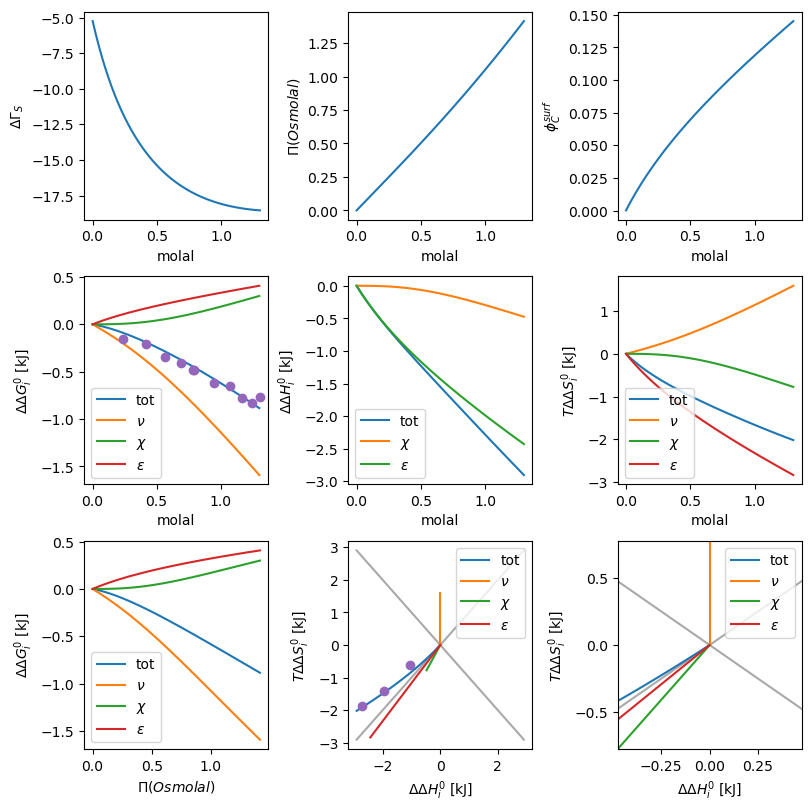

In [7]:
from fh_crowding.plotting import BinaryPlotter

plotter = BinaryPlotter(model)

# The plotter will overlay the experimental scatter points over the solved model lines
fig = plotter.plot_results(
    concentration_type='molal',
    exp_conc=exp_conc_G,
    exp_ddG=exp_dG,
    exp_ddH=exp_dH,
    exp_TddS=exp_TdS
)
plt.show()

## Exporting the Model Results
Now that the model is fully fitted and solved across the concentration grid, we can convert it to a DataFrame and export it.

In [8]:
# Convert model grid results to a dataframe
model.to_pandas()
results = model.results
display(results.head())

# Export the dataframe
# results.to_csv("aq16_trehalose_fitted_model.csv", index=False)

# You can also access the fitted parameters directly for export:
params_dict = {
    "eps": model.eps,
    "epsTS": model.epsTS
}
print(f"Final Parameters: {params_dict}")

,phiC,phiCsurf,phiS,phiSsurf,molar,molal,osm,gamma_per_vol,gamma,gammaC_per_vol,...,ddA_chi_kJ,ddA_eps_kJ,ddA_kJ,ddE_chi_kJ,ddE_eps_kJ,ddE_kJ,TddS_nu_kJ,TddS_chi_kJ,TddS_eps_kJ,TddS_kJ
0,0.0001,0.000091,0.9999,0.999909,0.000475,0.000475,0.000475,-0.092060,-5.251391,7.869129e-07,...,5.188910e-09,0.000255,-0.000111,-8.232751e-09,-0.001519,-0.001519,0.000366,-1.342166e-08,-0.001773,-0.001408
1,0.0051,0.004550,0.9949,0.995450,0.024217,0.024341,0.024316,-0.107930,-6.156702,4.728765e-05,...,1.855086e-05,0.012753,-0.006136,-2.943289e-05,-0.076098,-0.076127,0.018908,-4.798375e-05,-0.088851,-0.069992
2,0.0101,0.008861,0.9899,0.991139,0.047958,0.048448,0.048357,-0.122690,-6.998649,1.069925e-04,...,9.401533e-05,0.024839,-0.013054,-1.491652e-04,-0.148210,-0.148359,0.037987,-2.431805e-04,-0.173049,-0.135305
3,0.0151,0.013040,0.9849,0.986960,0.071700,0.072799,0.072613,-0.136444,-7.783209,1.787938e-04,...,2.598955e-04,0.036553,-0.020826,-4.123515e-04,-0.218107,-0.218520,0.057639,-6.722471e-04,-0.254660,-0.197694
4,0.0201,0.017099,0.9799,0.982901,0.095442,0.097399,0.097098,-0.149282,-8.515562,2.617198e-04,...,5.512470e-04,0.047933,-0.029413,-8.746113e-04,-0.286012,-0.286887,0.077898,-1.425858e-03,-0.333945,-0.257473


Final Parameters: {'eps': -0.045005772325464016, 'epsTS': 0.31354915422418717}
